<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day05_practice2_%EC%95%84%EC%9D%B4%EB%A6%AC%EC%8A%A4_%EB%8B%A4%EC%A4%91%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 아이리스 다중분류
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
# 셀 1. 데이터 - 붓꽃 150송이, 특징 4개, 품종 3가지
iris = load_iris()
X, y = iris.data, iris.target
classes = iris.target_names  # setosa / versicolor / virginica

print("특징 4개:", iris.feature_names)
print("클래스 3개:", classes.tolist())
print("모양:", X.shape, "|클래스별 개수: 각 50송이 (균형 데이터)")



특징 4개: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
클래스 3개: ['setosa', 'versicolor', 'virginica']
모양: (150, 4) |클래스별 개수: 각 50송이 (균형 데이터)


In [3]:
# 셀 2. 전처리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # stratify=y : 클래스 비율 유지
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long) # long(정수), CrossEntropyLoss의 요구
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=16, shuffle=True)



In [4]:
# 셀 3. 모델 - 출력층
class IrisNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(4,16),
        nn.ReLU(),
        nn.Linear(16,3),          # 출력 3 = 클래스 수, Softmax 없음!
    )
  def forward(self, x):
    return self.net(x)            # 로짓 반환

model = IrisNet().to(device)
loss_fn = nn.CrossEntropyLoss() # Softmax 내장
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [5]:
# 셀 4. 학습
for epoch in range(100):
  model.train()
  for X_b, y_b in train_loader:
    X_b, y_b = X_b.to(device), y_b.to(device)
    loss = loss_fn(model(X_b),y_b)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  if (epoch + 1) % 25 == 0:
    print(f"epoch{epoch+1:3d} | loss {loss.item():.4f}")

epoch 25 | loss 0.0058
epoch 50 | loss 0.0478
epoch 75 | loss 0.1335
epoch100 | loss 0.0006


In [12]:
# 셀 5. 평가 (argmax로 결정 + 확률로 들여다보기)
model.eval()
with torch.no_grad():
  logits = model(X_test_t.to(device)).cpu() # 결과를 CPU로 다시 가져온다
  preds = logits.argmax(dim=1) # 각 샘플(행)마다 점수가 가장 높은 클래스 번호를 뽑아 예측값으로 만든다

acc = (preds == y_test_t).float().mean().item() # 1과 0의 평균 = 맞힌 비율(정확도)
print(f"\n테스트 정확도: {acc:.4f} (30송이 중 {int(acc*30)}송이 정답)") # 비율을 다시 개수로 환산

# 확률로 들여다보기
probs = torch.softmax(logits, dim=1)
print("\n샘플 3송이와 예측 확률:")

for i in range(3):
  dist = " / ".join(f"{classes[j]} {probs[i,j]:.0%}" for j in range(3))
  mark = "O" if preds[i] == y_test_t[i] else "X"
  print(f"[{mark}] 정답 {classes[y_test_t[i]]:10s} -> {dist}")


테스트 정확도: 0.9333 (30송이 중 28송이 정답)

샘플 3송이와 예측 확률:
[O] 정답 setosa     -> setosa 100% / versicolor 0% / virginica 0%
[O] 정답 virginica  -> setosa 0% / versicolor 31% / virginica 69%
[O] 정답 versicolor -> setosa 1% / versicolor 98% / virginica 2%



혼동 행렬(행=정답, 열=예측):
                0        1        9


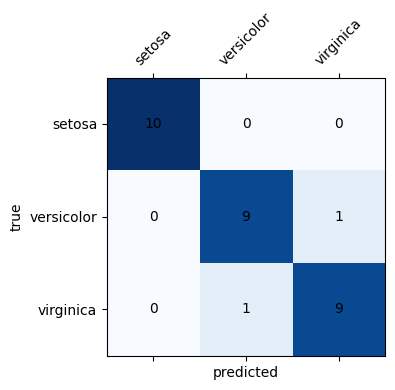

In [15]:
# 셀 6. 혼동 행렬 (무엇을 무엇으로 헷갈리나)

# 혼동 행렬(Confusion Matrix)를 만들어 텍스트로 출력하고, 히트맵으로 시각화하는 코드

cm = torch.zeros(3, 3, dtype=torch.int32)
for t, p in zip(y_test_t, preds):
  cm[t, p] += 1

print("\n혼동 행렬(행=정답, 열=예측):")
print("         " + " ".join(f"{cm[i,j].item():8d}" for j in range(3)))

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.matshow(cm, cmap="Blues")
ax.set_xticks(range(3), classes, rotation=45)
ax.set_yticks(range(3), classes)

for i in range(3):
  for j in range(3):
    ax.text(j, i, cm[i, j].item(), va="center", ha="center")

ax.set_xlabel("predicted")
ax.set_ylabel("true")

plt.tight_layout()
plt.savefig("plot1_confusion.png")
plt.show() # 혼동 행렬 - 대각선에 진할수록 좋은 모양

In [18]:
print(logits[:3]) # 출력을 점수 model(X_test_t)
print(preds[:3])  # logits.argmax(dim=1)
print(probs[:3])  # torch.softmax(logits, dim=1)

tensor([[  7.0583,  -6.7689, -10.3611],
        [ -6.3064,   0.3610,   1.1403],
        [ -3.2454,   1.8826,  -2.2139]])
tensor([0, 2, 1])
tensor([[1.0000e+00, 9.8841e-07, 2.7218e-08],
        [3.9972e-04, 3.1434e-01, 6.8527e-01],
        [5.7973e-03, 9.7794e-01, 1.6263e-02]])
